# Homework 6: Linear Regression Modeling and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


df = pd.read_csv("C:/Users/hwang/OneDrive/Documents/MC stuff/Spring 2026/DATA 101 Introduction to Data Science/Classwork/Datasets/Life_Expectancy_Data.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1649 entries, 0 to 1648
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Year                             1649 non-null   int64  
 2   Status                           1649 non-null   object 
 3   Life expectancy                  1649 non-null   float64
 4   Adult Mortality                  1649 non-null   int64  
 5   infant deaths                    1649 non-null   int64  
 6   Alcohol                          1649 non-null   float64
 7   percentage expenditure           1649 non-null   float64
 8   Hepatitis B                      1649 non-null   int64  
 9   Measles                          1649 non-null   int64  
 10   BMI                             1649 non-null   float64
 11  under-five deaths                1649 non-null   int64  
 12  Polio               

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

In [26]:
df = df.drop(columns=['Country', 'Year'])

df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})

df = df.fillna(df.mean())

X = df.drop(columns=['Life expectancy '])
y = df['Life expectancy ']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)})

ranked_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print(f"R-Squared Score: {r2:.4f}")
print("\nFeature Ranking (by Absolute Coefficient):")
print(ranked_features[['Feature', 'Coefficient']])

R-Squared Score: 0.8105

Feature Ranking (by Absolute Coefficient):
                            Feature  Coefficient
8                under-five deaths    -11.892135
2                     infant deaths    11.676781
18                        Schooling     2.652725
12                         HIV/AIDS    -2.602024
1                   Adult Mortality    -2.068296
17  Income composition of resources     1.625756
4            percentage expenditure     0.707995
7                              BMI      0.538715
3                           Alcohol    -0.455825
0                            Status     0.350829
11                      Diphtheria      0.320418
5                       Hepatitis B    -0.226244
10                Total expenditure     0.210803
9                             Polio     0.210759
15             thinness  1-19 years    -0.209451
16               thinness 5-9 years    -0.205675
6                          Measles     -0.069886
14                       Population     0.050909
1

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You should use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below: 

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatest than 5!

In [28]:
def calculate_manual_vif(df):
    vif_dict = {}
    features = df.columns
    
    for feature in features:
        y_temp = df[feature]
        X_temp = df.drop(columns=[feature])
        
        model_temp = LinearRegression()
        model_temp.fit(X_temp, y_temp)
        
        r_sq = model_temp.score(X_temp, y_temp)
        
        if r_sq == 1:
            vif = float('inf')
        else:
            vif = 1 / (1 - r_sq)
            
        vif_dict[feature] = vif
        
    return pd.DataFrame({'Feature': vif_dict.keys(), 'VIF': vif_dict.values()})

print("Manual Iterative VIF Removal")
while True:
    vif_df = calculate_manual_vif(X_vif)
    highest_vif_row = vif_df.sort_values("VIF", ascending=False).iloc[0]
    
    if highest_vif_row["VIF"] > 5:
        print(f"Removing '{highest_vif_row['Feature']}' (VIF: {highest_vif_row['VIF']:.2f})")
        X_vif = X_vif.drop(columns=[highest_vif_row["Feature"]])
    else:
        print("All remaining features have a VIF < 5.")
        break

print("\nFeature Set:")
print(calculate_manual_vif(X_vif))

Manual Iterative VIF Removal
All remaining features have a VIF < 5.

Feature Set:
                            Feature       VIF
0                            Status  1.823448
1                   Adult Mortality  1.784269
2                           Alcohol  2.213318
3            percentage expenditure  1.402596
4                       Hepatitis B  1.658079
5                          Measles   1.401157
6                              BMI   1.788327
7                under-five deaths   2.692277
8                             Polio  1.700815
9                 Total expenditure  1.117744
10                      Diphtheria   2.070829
11                         HIV/AIDS  1.482587
12                       Population  1.827125
13               thinness 5-9 years  1.953136
14  Income composition of resources  2.934928
15                        Schooling  3.485792


## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predictors remain the same as those of the Baseline Model?

In [30]:
X_train_vif, X_test_vif, y_train_vif, y_test_vif = train_test_split(
    X_vif, y, test_size=0.2, random_state=42)

vif_model = LinearRegression().fit(X_train_vif, y_train_vif)
y_pred_vif = vif_model.predict(X_test_vif)

r2_vif = r2_score(y_test_vif, y_pred_vif)
print(f"R-Squared Score: {r2_vif:.4f}")

vif_coefficients = pd.DataFrame({
    'Feature': X_vif.columns,
    'Coefficient': vif_model.coef_,
    'Abs_Coefficient': np.abs(vif_model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("\nFeature Ranking:")
print(vif_coefficients[['Feature', 'Coefficient']])

top_5_vif = vif_coefficients.head(5)['Feature'].tolist()
print(f"\nTop 5 Predictors (VIF Model): {top_5_vif}")

def simple_reg(feature):
    X_simple = df[[feature]].fillna(df[[feature]].mean())
    y_simple = df['Life expectancy ']
    X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
    model_s = LinearRegression().fit(X_tr, y_tr)
    return r2_score(y_te, model_s.predict(X_te))

print("\nIndividual Performance of Top 3 Stable Predictors:")
for f in top_5_vif[:3]:
    print(f"{f} Individual R2: {simple_reg(f):.3f}")

R-Squared Score: 0.8058

Feature Ranking:
                            Feature  Coefficient
15                        Schooling     2.744360
11                         HIV/AIDS    -2.617885
1                   Adult Mortality    -2.181967
14  Income composition of resources     1.732902
2                           Alcohol    -0.670894
3            percentage expenditure     0.668603
6                              BMI      0.598661
10                      Diphtheria      0.464776
7                under-five deaths     -0.446510
0                            Status     0.361663
13               thinness 5-9 years    -0.264147
4                       Hepatitis B    -0.259107
8                             Polio     0.236767
12                       Population     0.193608
9                 Total expenditure     0.185599
5                          Measles      0.126017

Top 5 Predictors (VIF Model): ['Schooling', ' HIV/AIDS', 'Adult Mortality', 'Income composition of resources', 'Alcohol']

I

Are the top 5 predictors remain the same as those of the Baseline Model?

No, in the baseline model Infant deaths is in the top 5 because they are essentially measuring the same variance. In the VIF-cleared model, one of those is removed, allowing a other variables like Schooling to become one of the top 5.

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?

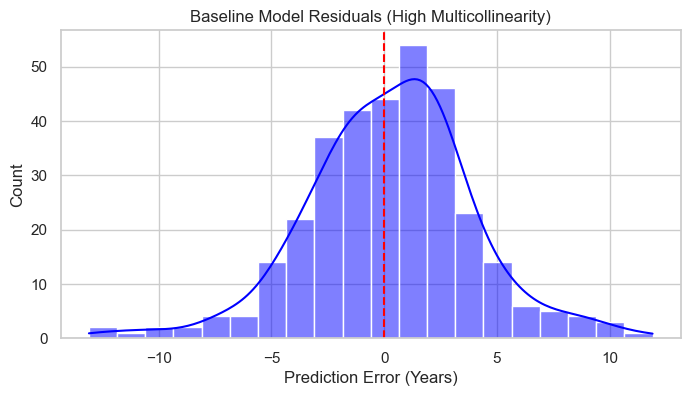

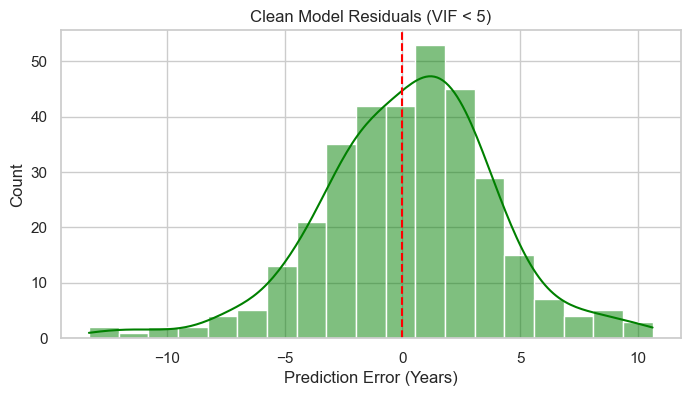

In [20]:
residuals_baseline = y_test - y_pred
residuals_clean = y_test_vif - y_pred_vif

# Baseline
plt.figure(figsize=(8, 4))
sns.histplot(residuals_baseline, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Baseline Model Residuals (High Multicollinearity)')
plt.xlabel('Prediction Error (Years)')
plt.show()

# Clean Model
plt.figure(figsize=(8, 4))
sns.histplot(residuals_clean, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--') # Add a line at zero
plt.title('Clean Model Residuals (VIF < 5)')
plt.xlabel('Prediction Error (Years)')
plt.show()

Does the error distributions look like a bell curve?

Yes, there is a bell curve distribution so the coefficients for factors like Schooling and HIV/AIDS are unbiased estimators on the impact of  life expectancy. 

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?

Two variables I chose: Measles and GDP

I think Measles and GDP interact because the impact of a highly contagious disease on life expectancy is likely mitigated by a country’s wealth, as higher GDP provides better access to vaccination programs and healthcare systems to manage outbreaks.

In [24]:
df['Measles_GDP'] = df['Measles '] * df['GDP']

X_inter = df[['Measles ', 'GDP', 'Measles_GDP']].fillna(df.mean())
y = df['Life expectancy '].fillna(df['Life expectancy '].mean())

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_inter_scaled = scaler.fit_transform(X_inter)

# Train the model
X_train, X_test, y_train, y_test = train_test_split(X_inter_scaled, y, test_size=0.2, random_state=42)
inter_model = LinearRegression().fit(X_train, y_train)

y_pred = inter_model.predict(X_test)
print(f"Interaction Model R-Squared: {r2_score(y_test, y_pred):.4f}")
print(f"Interaction Coefficient (Measles * GDP): {inter_model.coef_[2]:.4f}")

# Comparison 
coef_summary = pd.DataFrame({
    'Feature': ['Measles ', 'GDP', 'Measles_GDP'],
    'Coefficient': inter_model.coef_
})
print("\nModel Coefficients:")
print(coef_summary)

Interaction Model R-Squared: 0.1865
Interaction Coefficient (Measles * GDP): 0.8223

Model Coefficients:
       Feature  Coefficient
0     Measles     -0.862459
1          GDP     3.596729
2  Measles_GDP     0.822303


Is the interaction coeficient positive or negative? Has adding it improved the Model performance?

The interaction coefficient is positive (0.8223). This means that while Measles has a negative impact on life expectancy (-0.8624), the positive interaction suggests that as a country’s GDP increases, that negative impact is significantly mitigated. However, adding this did not improve the overall model performance. With an R^2 of 0.1865, this shows much less of variance in life expectancy than the diagnostic model (0.8058).